# Exploratory Data Analysis: AML Transactions
This notebook explores the `HI-Small_Trans.csv` dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
# Load the dataset
df = pd.read_csv('gs://junction-aml-quantum-bucket/HI-Small_Trans.csv')
df.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [1]:
df[df['From Bank'] = '001']

SyntaxError: cannot assign to subscript here. Maybe you meant '==' instead of '='? (1765043953.py, line 1)

In [3]:
# Display dataframe info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   Account             object 
 3   To Bank             int64  
 4   Account.1           object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 426.2+ MB


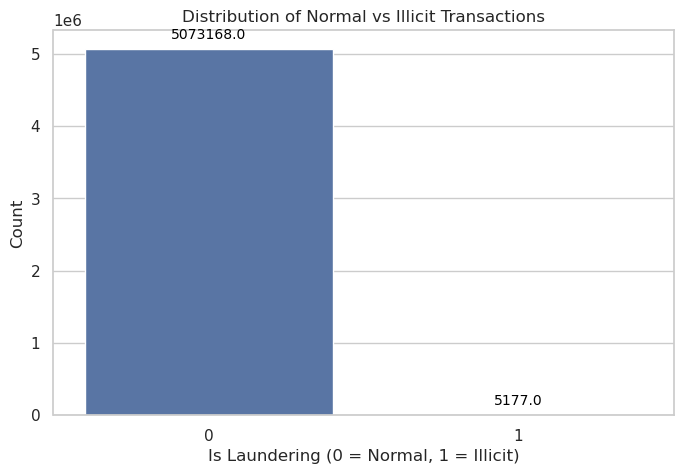

In [4]:
# Visualize the class distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Is Laundering')
plt.title('Distribution of Normal vs Illicit Transactions')
plt.xlabel('Is Laundering (0 = Normal, 1 = Illicit)')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

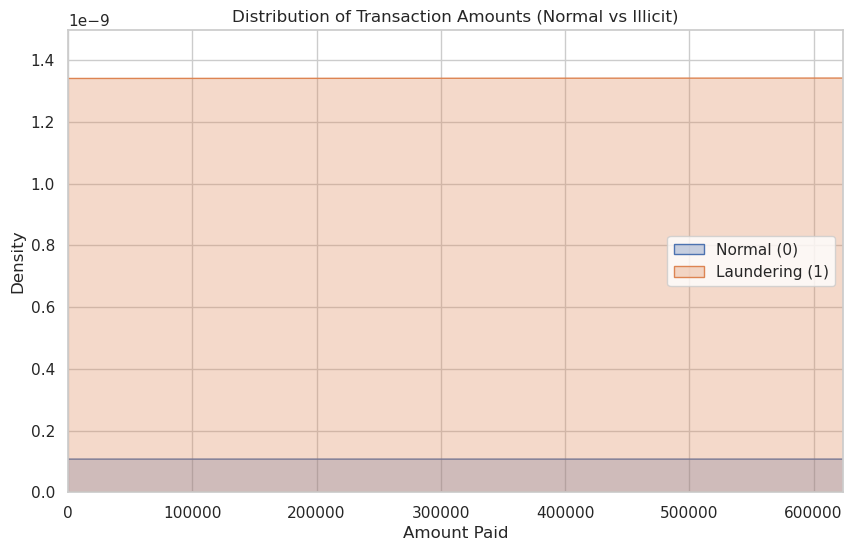

In [5]:
# Cell: Feature Distribution
plt.figure(figsize=(10, 6))
# Using 'Amount Paid' - adjust if the column name differs slightly in your CSV
sns.kdeplot(data=df[df['Is Laundering'] == 0], x='Amount Paid', label='Normal (0)', fill=True, alpha=0.3)
sns.kdeplot(data=df[df['Is Laundering'] == 1], x='Amount Paid', label='Laundering (1)', fill=True, alpha=0.3)
plt.title('Distribution of Transaction Amounts (Normal vs Illicit)')
plt.xlim(0, df['Amount Paid'].quantile(0.95)) # Zoom in to ignore extreme outliers
plt.legend()
plt.show()

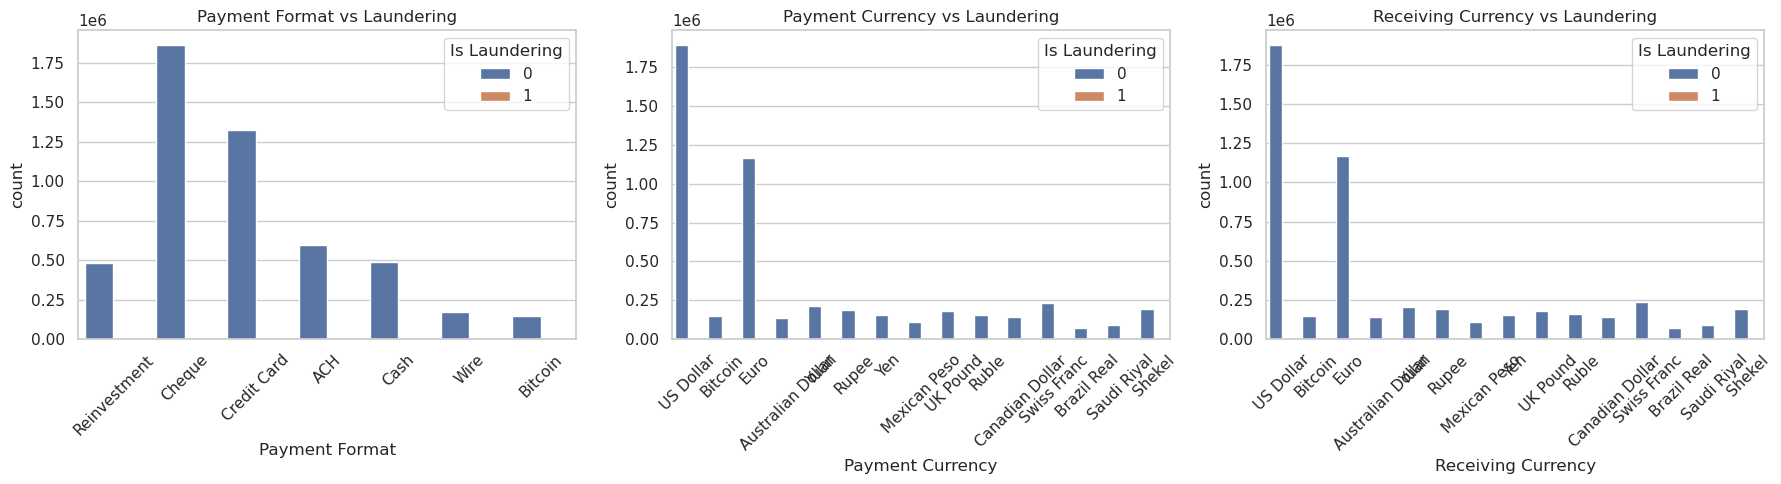

In [6]:
# Cell: Categorical Analysis
categorical_cols = ['Payment Format', 'Payment Currency', 'Receiving Currency']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(categorical_cols):
    if col in df.columns:
        sns.countplot(data=df, x=col, hue='Is Laundering', ax=axes[i])
        axes[i].set_title(f'{col} vs Laundering')
        axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


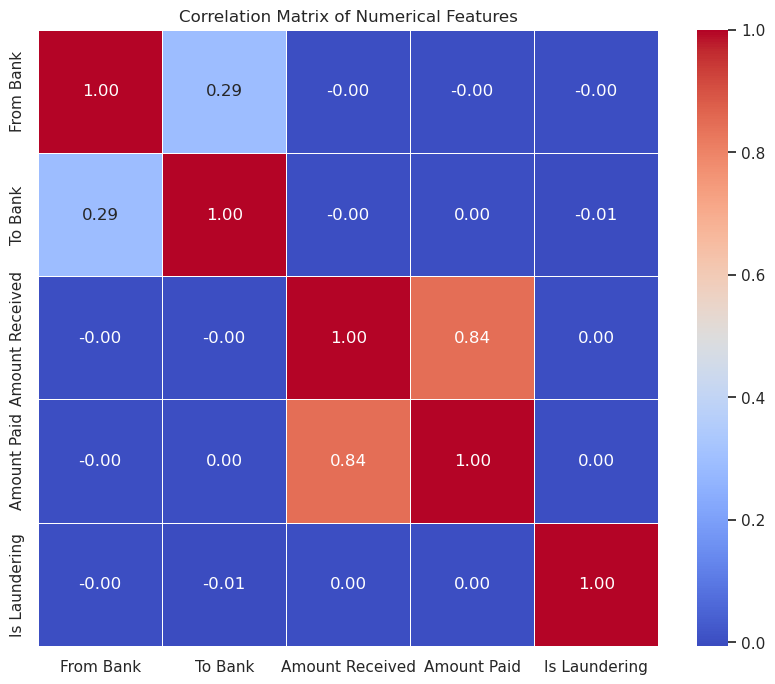

In [7]:
# Cell: Correlation Matrix
numerical_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()


Total Unique Banks: 30470

Top 5 Banks by transaction volume:
From Bank
70    449859
10     81629
12     79754
1      62211
15     52511
Name: count, dtype: int64


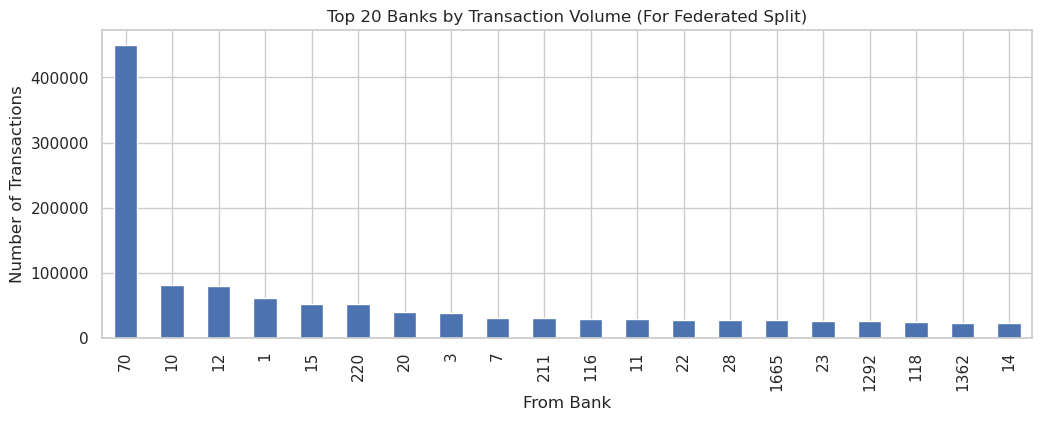

In [9]:
# Cell: Bank Analysis
if 'From Bank' in df.columns:
    print(f"Total Unique Banks: {df['From Bank'].nunique()}")
    print("\nTop 5 Banks by transaction volume:")
    print(df['From Bank'].value_counts().head(5))
    
    # Visualizing the split
    plt.figure(figsize=(12, 4))
    df['From Bank'].value_counts().head(20).plot(kind='bar')
    plt.title('Top 20 Banks by Transaction Volume (For Federated Split)')
    plt.ylabel('Number of Transactions')
    plt.show()


In [ ]:
# Cell: PCA Visualization
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.express as px

# 1. Quick preprocessing for PCA (using numeric data only for this quick viz)
pca_df = df.select_dtypes(include=['float64', 'int64']).fillna(0)
labels = pca_df.pop('Is Laundering') # Remove label from PCA

# 2. Standardize data (Crucial for PCA)
scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_df)

# 3. Run PCA down to 3 components
pca = PCA(n_components=3)
components = pca.fit_transform(pca_scaled)

# 4. Create 3D Scatter Plot
fig = px.scatter_3d(
    components, x=0, y=1, z=2, 
    color=labels.astype(str),
    labels={'0': 'PC 1', '1': 'PC 2', '2': 'PC 3', 'color': 'Is Laundering'},
    title='3D PCA of Transactions (Notice how anomalous data overlaps)',
    color_discrete_map={'0': 'blue', '1': 'red'},
    opacity=0.7
)

# For performance in notebook, plot only a sample if dataset is huge
if len(df) > 10000:
    print("Dataset is large, plotting a random 10,000 sample for 3D viz...")
    fig.update_traces(marker=dict(size=3))
    fig.show()
else:
    fig.show()


Dataset is large, plotting a random 10,000 sample for 3D viz...
